### PIZZA SALES ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px


## Import Raw Data

In [2]:
df = pd.read_csv("pizza_sales.csv")

## META DATA

In [4]:
df.head(10)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
5,6,2,thai_ckn_l,1,01-01-2015,11:57:40,20.75,20.75,L,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza
6,7,3,ital_supr_m,1,01-01-2015,12:12:28,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
7,8,3,prsc_argla_l,1,01-01-2015,12:12:28,20.75,20.75,L,Supreme,"Prosciutto di San Daniele, Arugula, Mozzarella...",The Prosciutto and Arugula Pizza
8,9,4,ital_supr_m,1,01-01-2015,12:16:31,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
9,10,5,ital_supr_m,1,01-01-2015,12:21:30,16.50,16.50,M,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza


In [5]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [6]:
print("The meta data of the dataset: ",df.shape)

The meta data of the dataset:  (48620, 12)


In [7]:
df.columns


Index(['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date',
       'order_time', 'unit_price', 'total_price', 'pizza_size',
       'pizza_category', 'pizza_ingredients', 'pizza_name'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [9]:
df.describe()

,pizza_id,order_id,quantity,unit_price,total_price
count,48620.000000,48620.000000,48620.000000,48620.000000,48620.000000
mean,24310.500000,10701.479761,1.019622,16.494132,16.821474
std,14035.529381,6180.119770,0.143077,3.621789,4.437398
min,1.000000,1.000000,1.000000,9.750000,9.750000
25%,12155.750000,5337.000000,1.000000,12.750000,12.750000
50%,24310.500000,10682.500000,1.000000,16.500000,16.500000
75%,36465.250000,16100.000000,1.000000,20.250000,20.500000
max,48620.000000,21350.000000,4.000000,35.950000,83.000000


# KPI

In [21]:
total_revenue = df['total_price'].sum()
total_pizzas_sold = df['quantity'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = total_revenue / total_orders
avg_pizzas_per_order = total_pizzas_sold / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Total Pizza Sold: {total_pizzas_sold:,}")
print(f"Average Pizza Per Order: {avg_pizzas_per_order:,.2f}")
    

Total Revenue: $817,860.05
Total Orders: 21,350
Average Order Value: $38.31
Total Pizza Sold: 49,574
Average Pizza Per Order: 2.32


# CHARTS

#### INGREDIENTS ANALYSIS

In [25]:
ingredient = (
    df['pizza_ingredients']
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
        .reset_index()
        .rename(columns={'index':'counts','pizza_ingredients': 'Ingredients'})
)
print(ingredient)

           Ingredients  count
0               Garlic  27422
1             Tomatoes  26601
2           Red Onions  19547
3          Red Peppers  16284
4    Mozzarella Cheese  10333
..                 ...    ...
60   Brie Carre Cheese    480
61          Prosciutto    480
62  Caramelized Onions    480
63               Pears    480
64               Thyme    480

[65 rows x 2 columns]


## Daily Trends

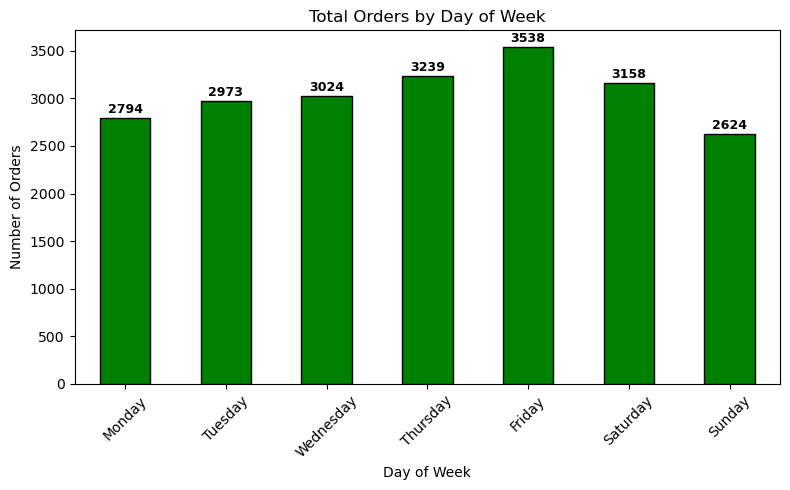

In [26]:
# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract day names
df['day_name'] = df['order_date'].dt.day_name()

# Define weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Make 'day_name' a categorical with the correct order
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

# Group by day_name and count unique orders
orders_by_day = df.groupby('day_name', observed=False)['order_id'].nunique()

# Plotting
ax = orders_by_day.plot(kind='bar', figsize=(8,5), color='green', edgecolor='black')

# Labels and title
plt.title("Total Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

# Add values on top of bars
for i, val in enumerate(orders_by_day):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

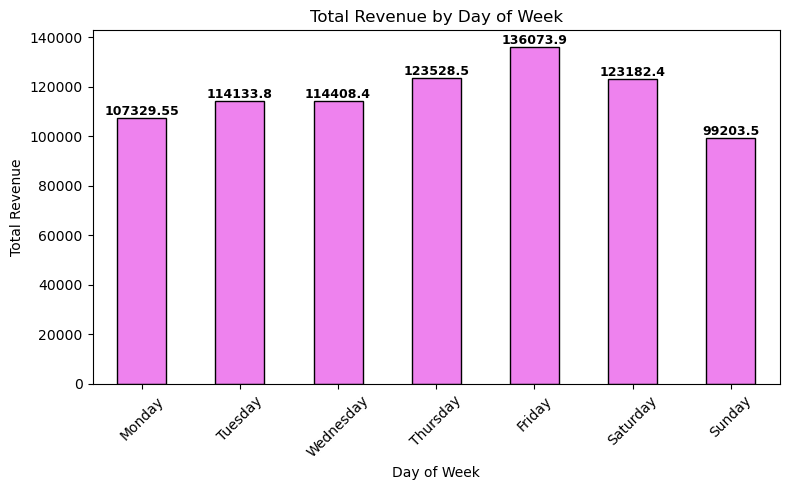

In [29]:
# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract day names
df['day_name'] = df['order_date'].dt.day_name()

# Define weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Make 'day_name' a categorical with the correct order
df['day_name'] = pd.Categorical(df['day_name'], categories=weekday_order, ordered=True)

# Group by day_name and count unique orders
orders_by_day = df.groupby('day_name', observed=False)['total_price'].sum()

# Plotting
ax = orders_by_day.plot(kind='bar', figsize=(8,5), color='violet', edgecolor='black')

# Labels and title
plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

# Add values on top of bars
for i, val in enumerate(orders_by_day):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

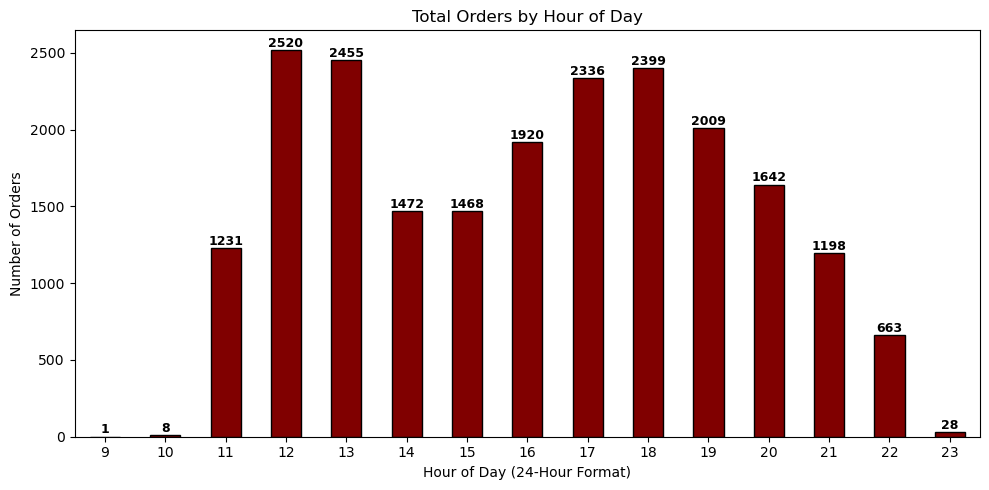

In [30]:
# Convert 'order_time' to datetime
df['order_time'] = pd.to_datetime(df['order_time'], format='%H:%M:%S')

# Extract hour from 'order_time'
df['order_hour'] = df['order_time'].dt.hour

# Group by hour and count unique orders
orders_by_hour = df.groupby('order_hour', observed=False)['order_id'].nunique()

# Plot bar chart
ax = orders_by_hour.plot(kind='bar', figsize=(10,5), color='maroon', edgecolor='black')

# Set titles and labels
plt.title("Total Orders by Hour of Day")
plt.xlabel("Hour of Day (24-Hour Format)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

# Add values on top of bars
for i, val in enumerate(orders_by_hour.values):
    plt.text(i, val + 0.5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

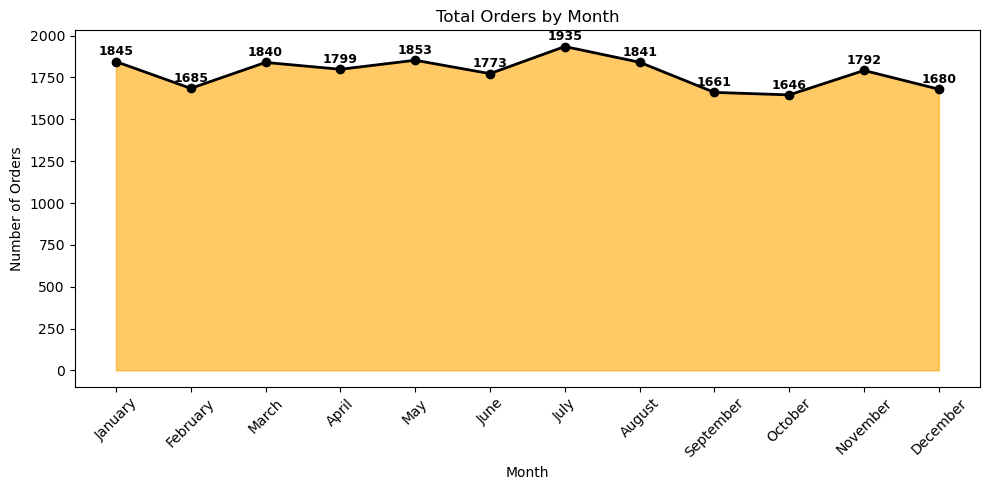

In [31]:
# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

# Extract month names
df['month_name'] = df['order_date'].dt.month_name()

# Define month order
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# Make 'month_name' a categorical variable with order
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)

# Group orders by month
orders_by_month = df.groupby('month_name', observed=False)['order_id'].nunique()

# Plot
plt.figure(figsize=(10,5))
plt.fill_between(orders_by_month.index, orders_by_month.values, color="orange", alpha=0.6)
plt.plot(orders_by_month.index, orders_by_month.values, color="black", linewidth=2, marker='o')

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

# Annotate values
for i, val in enumerate(orders_by_month):
    plt.text(i, val + 20, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

pizza_category
Chicken    23.955138
Classic    26.905960
Supreme    25.456311
Veggie     23.682591
Name: total_price, dtype: float64


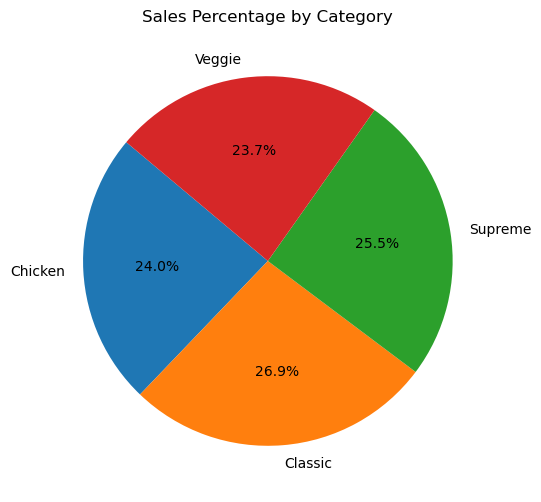

In [32]:
# Group by category and sum sales
category_sales = df.groupby('pizza_category')['total_price'].sum()

# Calculate percentage
category_percentage = (category_sales / category_sales.sum()) * 100

# Print percentage
print(category_percentage)

# Plot pie chart
plt.figure(figsize=(8, 6))
category_percentage.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Sales Percentage by Category')
plt.ylabel('')  # remove y-label for cleaner look
plt.show()

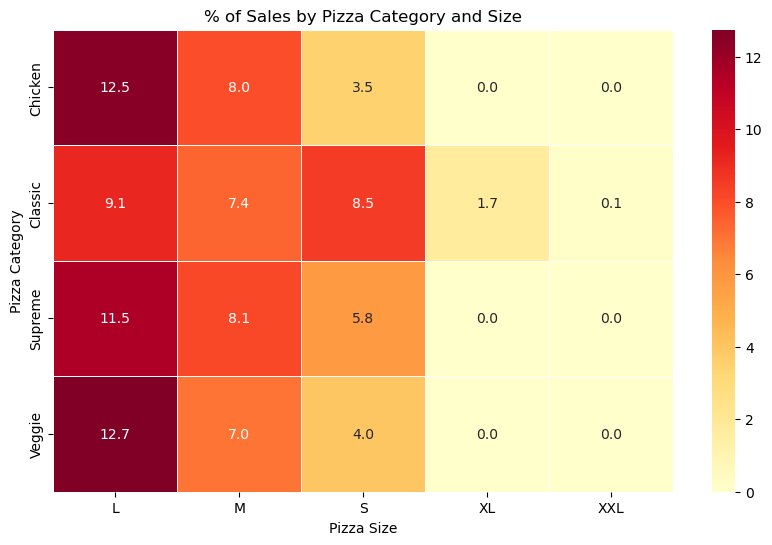

In [33]:
sales_pivot = df.pivot_table(
    index='pizza_category',
    columns='pizza_size',
    values='total_price',
    aggfunc='sum',
    fill_value=0
)

sales_pct = sales_pivot / sales_pivot.sum().sum() * 100

plt.figure(figsize=(10, 6))
sns.heatmap(sales_pct, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5)
plt.title("% of Sales by Pizza Category and Size")
plt.ylabel("Pizza Category")
plt.xlabel("Pizza Size")
plt.show()

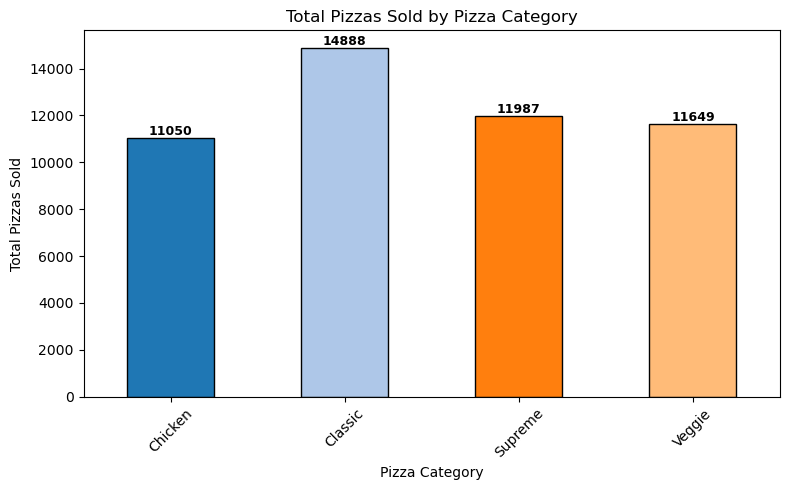

In [34]:
pizzas_by_category = df.groupby('pizza_category')['quantity'].sum()

colors = list(plt.get_cmap('tab20').colors)
colors = colors[:len(pizzas_by_category)]

ax = pizzas_by_category.plot(kind='bar', figsize=(8,5), color=colors, edgecolor='black')

plt.title("Total Pizzas Sold by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(pizzas_by_category):
    plt.text(i, val + 5, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

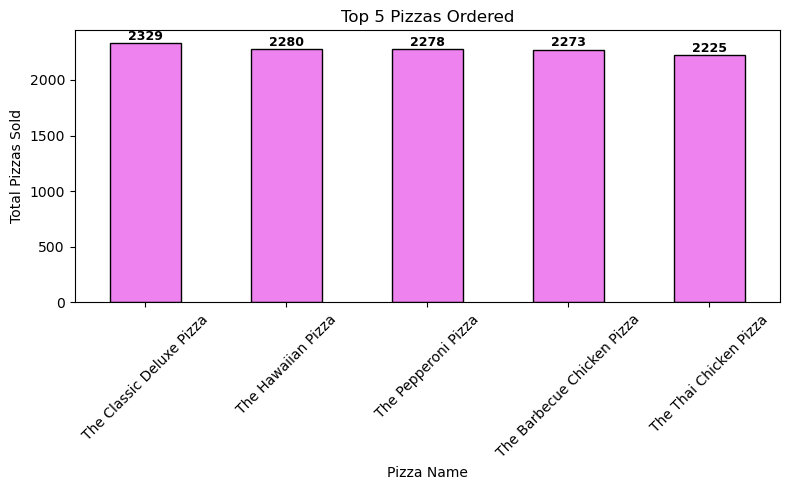

In [35]:
pizzas_by_name = df.groupby('pizza_name')['order_id'].nunique()

top5 = pizzas_by_name.sort_values(ascending=False).head(5)

ax = top5.plot(kind='bar', figsize=(8,5), color='violet', edgecolor='black')
plt.title("Top 5 Pizzas Ordered")
plt.xlabel("Pizza Name")
plt.ylabel("Total Pizzas Sold")
plt.xticks(rotation=45)

for i, val in enumerate(top5):
    plt.text(i, val + 2, str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()